# NBA Player Performance vs. Salary Analysis

### Benjamin Sillman — DS150 Capstone Project

Question: Are NBA players being paid in proportion to their on-court performance?

In this project I am looking at NBA player stats and salaries from the 2022-23 season to see if the highest paid players are actually the best performers. I used two datasets from Kaggle, cleaned and merged them, and analyzed the relationship between salary and on-court production across multiple stats.

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
stats = pd.read_csv('all_seasons.csv')
salaries = pd.read_csv('nba_player_salaries.csv')

print(stats.shape)
print(salaries.shape)

(12844, 22)
(574, 6)


## 2. Filtering & Cleaning

In [2]:
# Filter stats to 2022-23 season
stats_2223 = stats[stats['season'] == '2022-23']

print(stats_2223.shape)
print(stats_2223.head())

(539, 22)
       Unnamed: 0       player_name team_abbreviation   age  player_height  \
12305       12305    Quentin Grimes               NYK  23.0         195.58   
12306       12306   Quenton Jackson               WAS  24.0         195.58   
12307       12307   Pat Connaughton               MIL  30.0         195.58   
12308       12308        RJ Barrett               NYK  23.0         198.12   
12309       12309  Precious Achiuwa               TOR  23.0         203.20   

       player_weight     college  country draft_year draft_round  ...   pts  \
12305      95.254320     Houston      USA       2021           1  ...  11.3   
12306      78.471416   Texas A&M      USA  Undrafted   Undrafted  ...   6.2   
12307      94.800728  Notre Dame      USA       2015           2  ...   7.6   
12308      97.068688        Duke   Canada       2019           1  ...  19.6   
12309     102.058200     Memphis  Nigeria       2020           1  ...   9.2   

       reb  ast  net_rating  oreb_pct  dreb_pc

In [3]:
# Clean player names
stats_2223 = stats_2223.copy()
stats_2223['player_name_clean'] = stats_2223['player_name'].str.strip().str.lower()

salaries['player_name_clean'] = salaries['Player Name'].str.strip().str.lower()

# Clean salary column - remove $ and commas, convert to number
salaries['salary_2223'] = salaries['2022/2023'].str.replace('$', '').str.replace(',', '').str.strip()
salaries['salary_2223'] = pd.to_numeric(salaries['salary_2223'])

print(salaries[['Player Name', 'salary_2223']].head())

         Player Name  salary_2223
0      Stephen Curry     48070014
1          John Wall     47345760
2  Russell Westbrook     47080179
3       LeBron James     44474988
4       Kevin Durant     44119845


## 3. Merging

In [4]:
# Merge on cleaned player name
merged = stats_2223.merge(salaries[['player_name_clean', 'salary_2223']], on='player_name_clean', how='inner')

print(merged.shape)
print(merged[['player_name', 'pts', 'reb', 'ast', 'net_rating', 'ts_pct', 'usg_pct', 'gp', 'salary_2223']].head())

(483, 24)
        player_name   pts  reb  ast  net_rating  ts_pct  usg_pct  gp  \
0    Quentin Grimes  11.3  3.2  2.1         4.4   0.619    0.142  71   
1   Quenton Jackson   6.2  0.9  1.7        -6.7   0.542    0.164   9   
2   Pat Connaughton   7.6  4.6  1.3         3.4   0.531    0.133  61   
3        RJ Barrett  19.6  5.0  2.8        -1.2   0.531    0.256  73   
4  Precious Achiuwa   9.2  6.0  0.9        -1.6   0.554    0.190  55   

   salary_2223  
0      2277000  
1       219630  
2      5728393  
3     10900634  
4      2840160  


In [5]:
# Filter out players with fewer than 10 games played
merged = merged[merged['gp'] >= 10]

print(merged.shape)

(420, 24)


## 4. Analysis

In [6]:
# Sort by salary to see top 10 highest paid players
top10_paid = merged.sort_values('salary_2223', ascending=False).head(10)

print(top10_paid[['player_name', 'salary_2223', 'pts', 'reb', 'ast', 'net_rating']])

# Print a summary for each player in the top 10
for i in range(len(top10_paid)):
    player = top10_paid.iloc[i]
    print(f"{player['player_name']} — Salary: ${player['salary_2223']:,.0f} | PTS: {player['pts']} | Net Rating: {player['net_rating']}")

               player_name  salary_2223   pts   reb  ast  net_rating
109          Stephen Curry     48070014  29.4   6.1  6.3         5.8
461              John Wall     47345760  11.4   2.7  5.2        -6.6
16       Russell Westbrook     47080179  15.9   5.8  7.5        -0.2
381           LeBron James     44474988  28.9   8.3  6.8         4.6
320           Kevin Durant     44119845  29.1   6.7  5.0         6.8
243           Bradley Beal     43279250  23.2   3.9  5.4         0.7
9              Paul George     42492492  23.8   6.1  5.1         4.0
225         Damian Lillard     42492492  32.2   4.8  7.3         2.1
346          Kawhi Leonard     42492492  23.8   6.5  3.9         6.1
185  Giannis Antetokounmpo     42492492  31.1  11.8  5.7         7.2
Stephen Curry — Salary: $48,070,014 | PTS: 29.4 | Net Rating: 5.8
John Wall — Salary: $47,345,760 | PTS: 11.4 | Net Rating: -6.6
Russell Westbrook — Salary: $47,080,179 | PTS: 15.9 | Net Rating: -0.2
LeBron James — Salary: $44,474,988 | PTS:

In [7]:
# Most overpaid - high salary, low net rating
overpaid = merged[merged['salary_2223'] > 20000000].sort_values('net_rating', ascending=True).head(10)
print("Most Overpaid Players (high salary, low net rating):")
print(overpaid[['player_name', 'salary_2223', 'net_rating']])

# Most underpaid - low salary, high net rating
underpaid = merged[merged['salary_2223'] < 5000000].sort_values('net_rating', ascending=False).head(10)
print("\nMost Underpaid Players (low salary, high net rating):")
print(underpaid[['player_name', 'salary_2223', 'net_rating']])

Most Overpaid Players (high salary, low net rating):
           player_name  salary_2223  net_rating
461          John Wall     47345760        -6.6
135       Terry Rozier     21486316        -6.2
188     Gordon Hayward     30075000        -3.3
299        Buddy Hield     21177750        -1.9
246    Anfernee Simons     22321429        -1.6
469       Jerami Grant     20955000        -1.2
40        Myles Turner     35096500        -1.2
66      Nikola Vucevic     22000000        -0.5
480       John Collins     23500000        -0.2
16   Russell Westbrook     47080179        -0.2

Most Underpaid Players (low salary, high net rating):
          player_name  salary_2223  net_rating
315     Isaiah Mobley       508891        19.8
237  Boban Marjanovic      4101478        18.5
384  Lindy Waters III      2316876        10.5
456       Josh Minott      1017781        10.4
235     Blake Griffin      2905851         9.9
127      Tony Bradley      2036318         9.9
147      Desmond Bane      2130240 

## 5. Visualizations

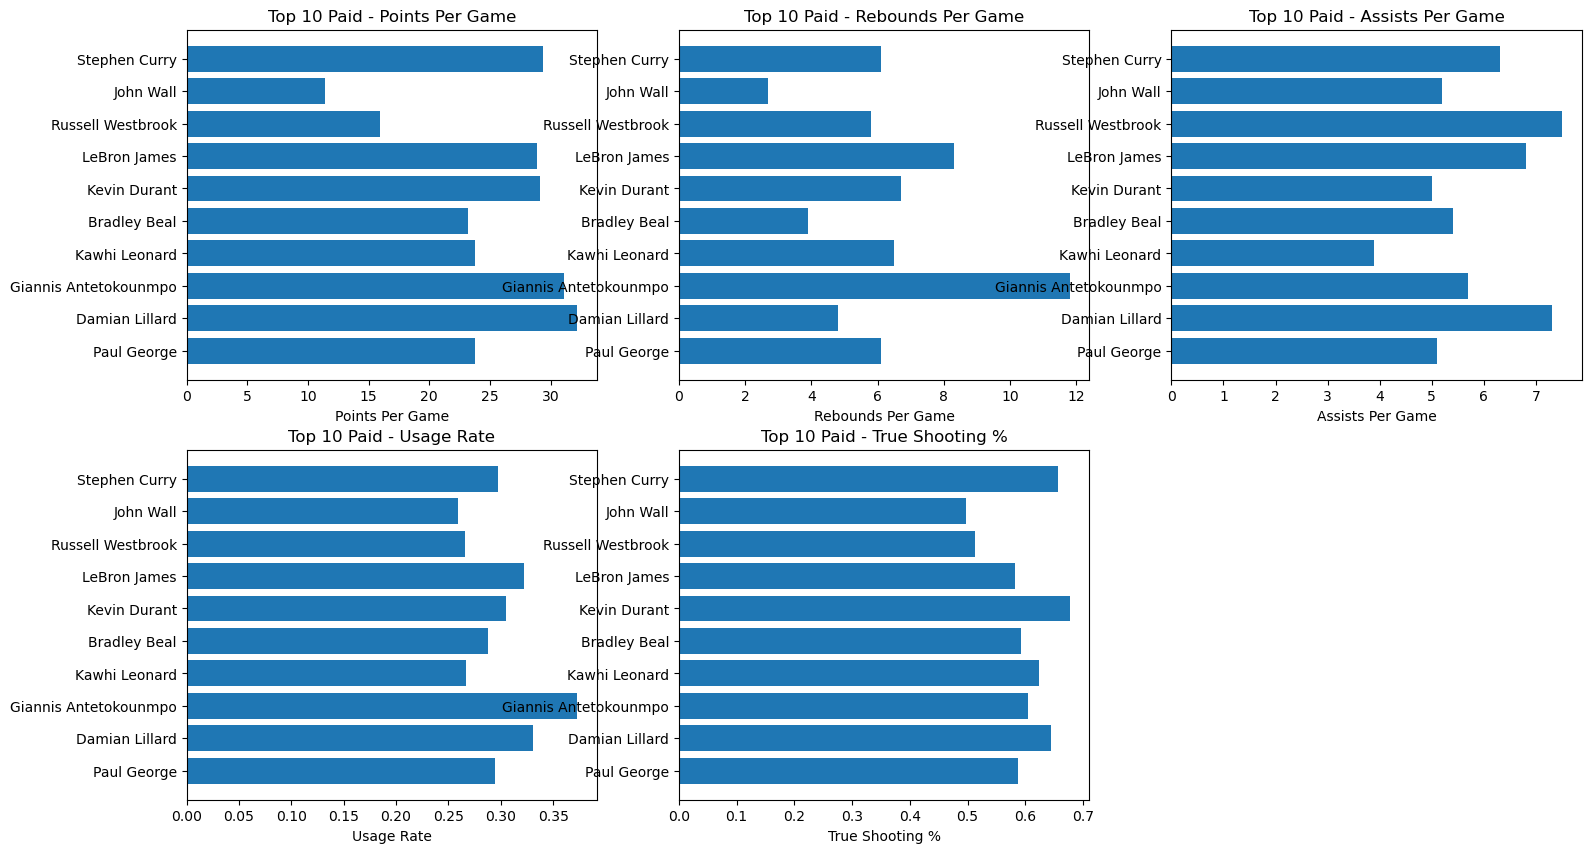

In [8]:
# Bar charts - Salary Vs In Game Stats
top10_sorted = top10_paid.sort_values('salary_2223', ascending=True)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].barh(top10_sorted['player_name'], top10_sorted['pts'])
axes[0, 0].set_xlabel('Points Per Game')
axes[0, 0].set_title('Top 10 Paid - Points Per Game')

axes[0, 1].barh(top10_sorted['player_name'], top10_sorted['reb'])
axes[0, 1].set_xlabel('Rebounds Per Game')
axes[0, 1].set_title('Top 10 Paid - Rebounds Per Game')

axes[0, 2].barh(top10_sorted['player_name'], top10_sorted['ast'])
axes[0, 2].set_xlabel('Assists Per Game')
axes[0, 2].set_title('Top 10 Paid - Assists Per Game')

axes[1, 0].barh(top10_sorted['player_name'], top10_sorted['usg_pct'])
axes[1, 0].set_xlabel('Usage Rate')
axes[1, 0].set_title('Top 10 Paid - Usage Rate')

axes[1, 1].barh(top10_sorted['player_name'], top10_sorted['ts_pct'])
axes[1, 1].set_xlabel('True Shooting %')
axes[1, 1].set_title('Top 10 Paid - True Shooting %')

axes[1, 2].set_visible(False)

plt.show()

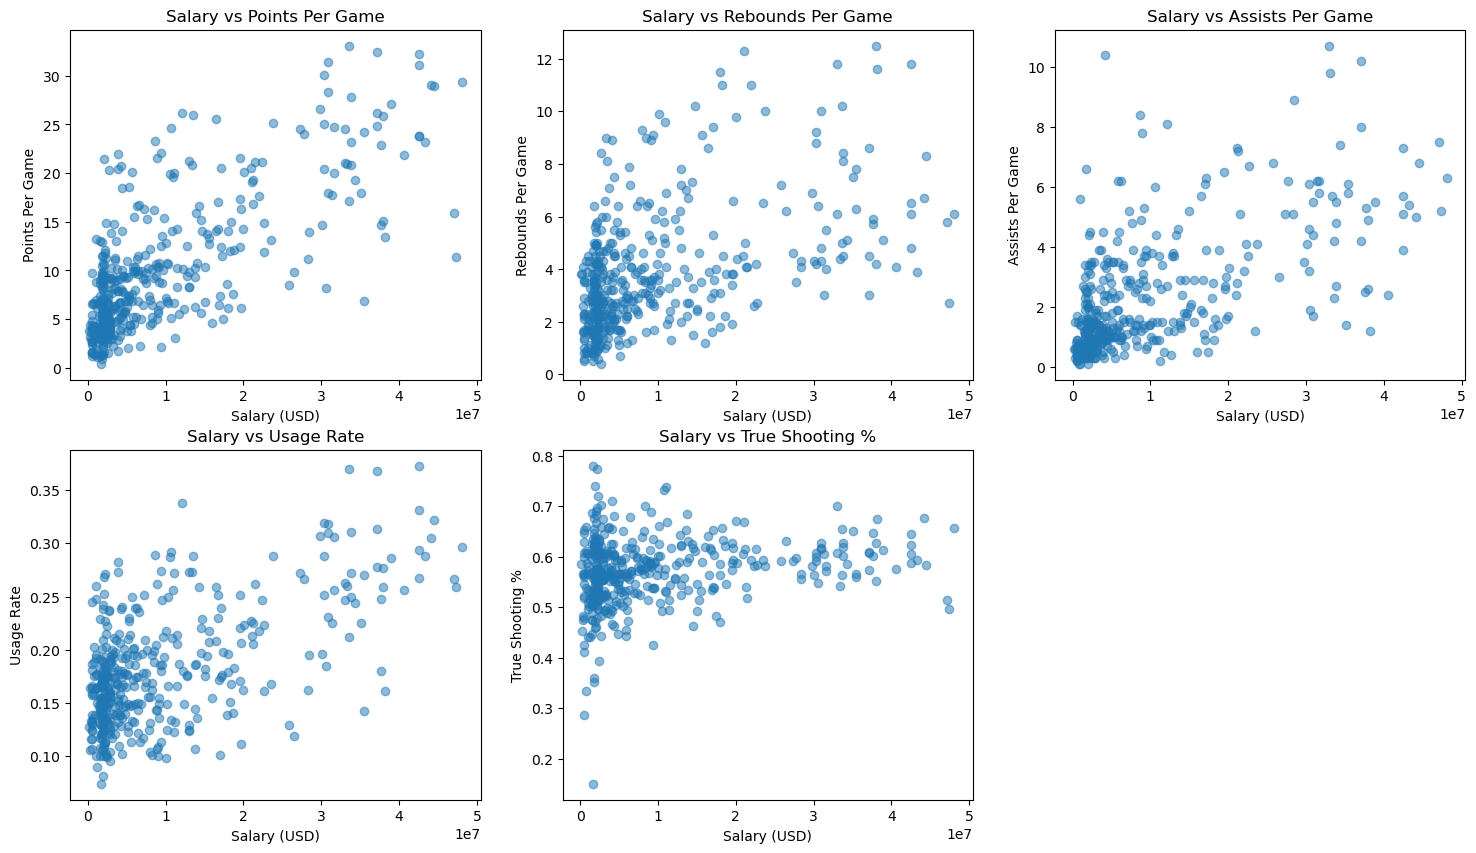

In [9]:
# Scatter plots - Salary vs In Game Stats
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(merged['salary_2223'], merged['pts'], alpha=0.5)
axes[0, 0].set_xlabel('Salary (USD)')
axes[0, 0].set_ylabel('Points Per Game')
axes[0, 0].set_title('Salary vs Points Per Game')

axes[0, 1].scatter(merged['salary_2223'], merged['reb'], alpha=0.5)
axes[0, 1].set_xlabel('Salary (USD)')
axes[0, 1].set_ylabel('Rebounds Per Game')
axes[0, 1].set_title('Salary vs Rebounds Per Game')

axes[0, 2].scatter(merged['salary_2223'], merged['ast'], alpha=0.5)
axes[0, 2].set_xlabel('Salary (USD)')
axes[0, 2].set_ylabel('Assists Per Game')
axes[0, 2].set_title('Salary vs Assists Per Game')

axes[1, 0].scatter(merged['salary_2223'], merged['usg_pct'], alpha=0.5)
axes[1, 0].set_xlabel('Salary (USD)')
axes[1, 0].set_ylabel('Usage Rate')
axes[1, 0].set_title('Salary vs Usage Rate')

axes[1, 1].scatter(merged['salary_2223'], merged['ts_pct'], alpha=0.5)
axes[1, 1].set_xlabel('Salary (USD)')
axes[1, 1].set_ylabel('True Shooting %')
axes[1, 1].set_title('Salary vs True Shooting %')

axes[1, 2].set_visible(False)

plt.show()

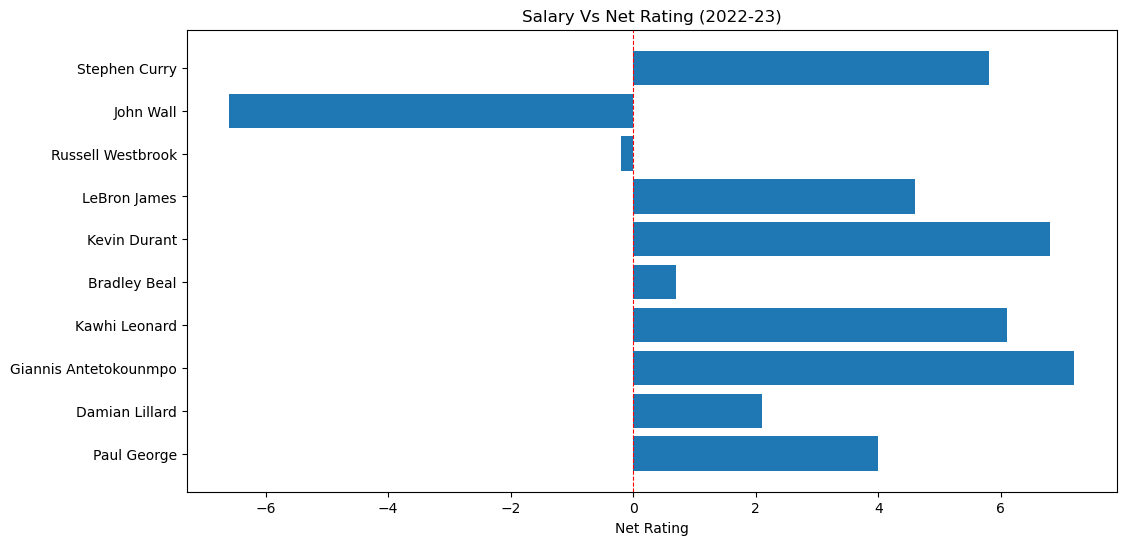

In [10]:
# Bar chart - Salary Vs Net Rating
plt.figure(figsize=(12, 6))
plt.barh(top10_sorted['player_name'], top10_sorted['net_rating'])
plt.xlabel('Net Rating')
plt.title('Salary Vs Net Rating (2022-23)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.show()

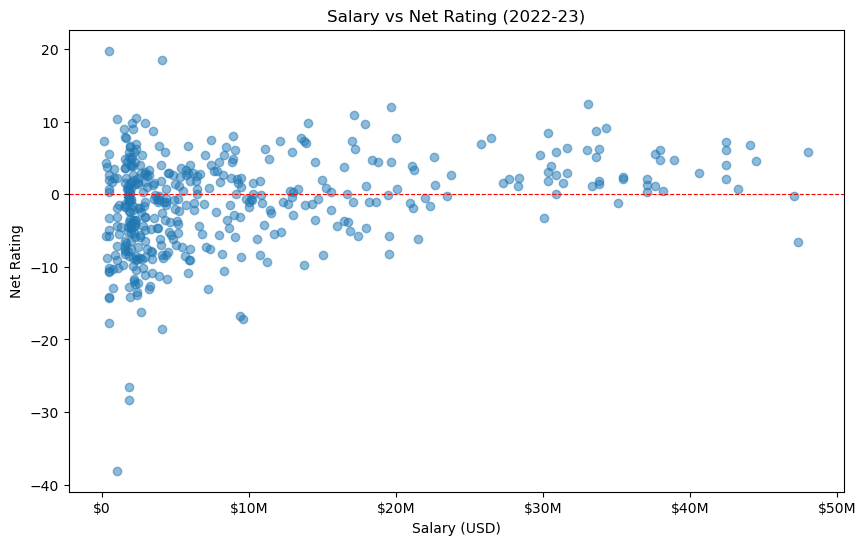

In [11]:
# Scatter plot - Salary vs Net Rating
plt.figure(figsize=(10, 6))
plt.scatter(merged['salary_2223'], merged['net_rating'], alpha=0.5)
plt.xlabel('Salary (USD)')
plt.ylabel('Net Rating')
plt.title('Salary vs Net Rating (2022-23)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.xticks(ticks=[0, 10000000, 20000000, 30000000, 40000000, 50000000], 
           labels=['$0', '$10M', '$20M', '$30M', '$40M', '$50M'])
plt.show()

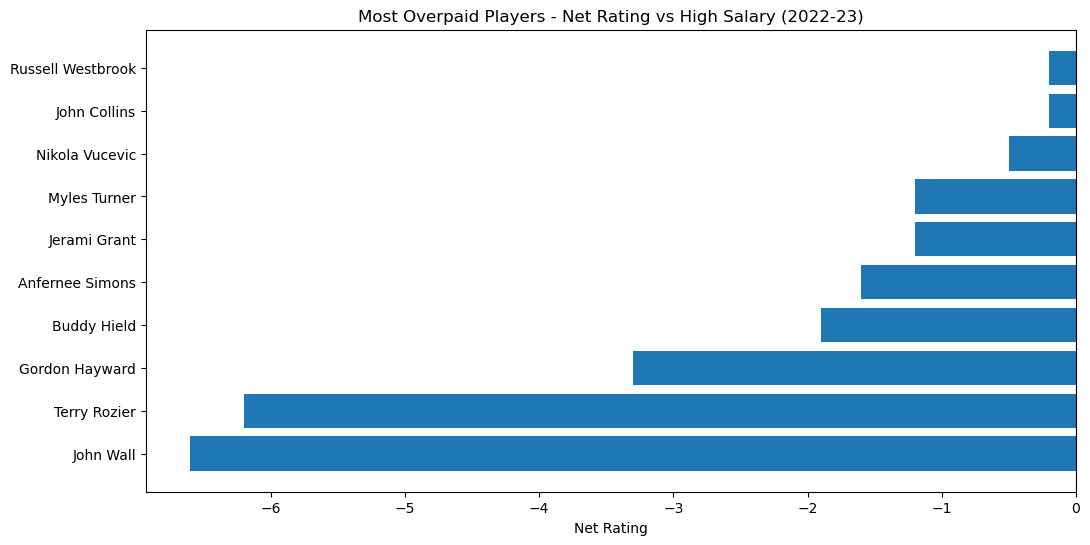

In [12]:
# Bar chart - Most Overpaid Players
plt.figure(figsize=(12, 6))
plt.barh(overpaid['player_name'], overpaid['net_rating'])
plt.xlabel('Net Rating')
plt.title('Most Overpaid Players - Net Rating vs High Salary (2022-23)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.show()

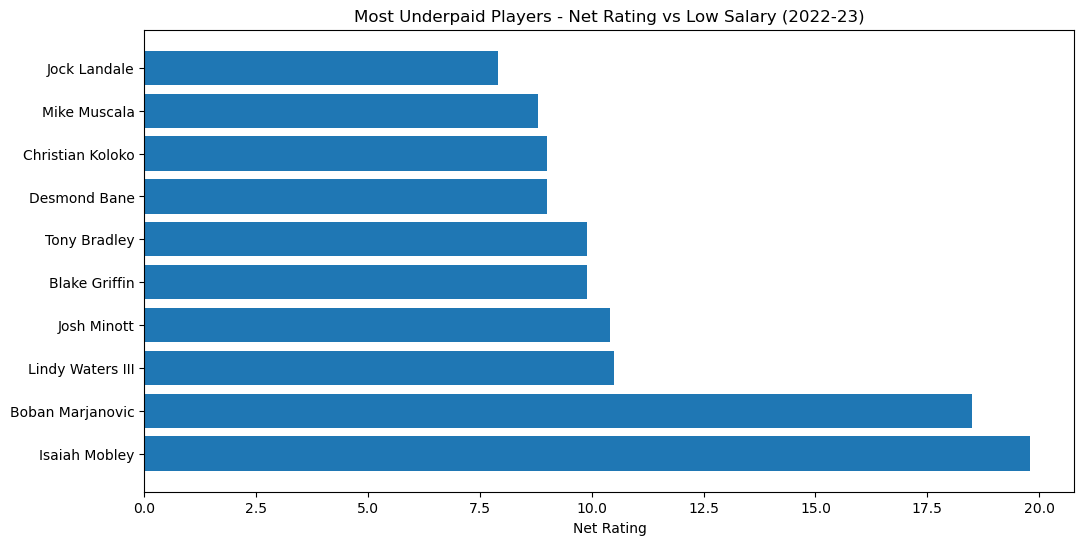

In [13]:
# Bar chart - Most Underpaid Players
plt.figure(figsize=(12, 6))
plt.barh(underpaid['player_name'], underpaid['net_rating'])
plt.xlabel('Net Rating')
plt.title('Most Underpaid Players - Net Rating vs Low Salary (2022-23)')
plt.show()

## 6. Key Findings
- Higher paid players generally scored more points, grabbed more rebounds, and had higher usage rates, showing a loose correlation between salary and production.

- Net rating told a different story — players like John Wall and Russell Westbrook were making $47M but had negative net ratings, meaning their teams actually performed worse with them on the court.

- The most underpaid players like Isaiah Mobley and Boban Marjanovic had some of the highest net ratings in the league while making under $5M, making them the best value contracts of the 2022-23 season.